# Chapitre 6 — Apprentissage par Renforcement (Reinforcement Learning)
## Modélisation Stochastique et Optimisation de la Sécurité des Réseaux Informatiques

**Module :** Apprentissage Probabiliste — Prof. Nizar Ben Kasmia  
**Dataset :** UNSW-NB15 — Network Intrusion Detection  
**Algorithmes couverts :** Q-Learning · SARSA · TD(0) · TD(λ) · R-Learning

---

### Plan
1. Introduction au Reinforcement Learning
2. Environnement de Sécurité Réseau (UNSW-NB15)
3. **Q-Learning** (off-policy, TD control)
4. **SARSA** (on-policy, TD control)
5. **TD(0)** (prédiction de valeur)
6. **TD(λ)** — Eligibility Traces
7. **R-Learning** (average reward, sans facteur γ)
8. Comparaison des algorithmes
9. Visualisations complètes


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from collections import defaultdict

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('=' * 70)
print('  CHAPITRE 6 — Apprentissage par Renforcement')
print('  Dataset : UNSW-NB15 | Sécurité des Réseaux')
print('  Algorithmes : Q-Learning · SARSA · TD(0) · TD(λ) · R-Learning')
print('=' * 70)


  CHAPITRE 6 — Apprentissage par Renforcement
  Dataset : UNSW-NB15 | Sécurité des Réseaux
  Algorithmes : Q-Learning · SARSA · TD(0) · TD(λ) · R-Learning


---
## PARTIE 0 — Chargement du Dataset UNSW-NB15


In [2]:
# ============================================================
# CHARGEMENT UNSW-NB15  (adapter le chemin si nécessaire)
# ============================================================
TRAIN_PATH = r'C:\Users\Fujitsu\Desktop\Data science\S3\ML probabilistique\project of module\projet_cybersecurity\dataset\CSV Files\Training and Testing Sets\UNSW_NB15_training-set.csv'
TEST_PATH  = r'C:\Users\Fujitsu\Desktop\Data science\S3\ML probabilistique\project of module\projet_cybersecurity\dataset\CSV Files\Training and Testing Sets\UNSW_NB15_testing-set.csv'

FEATURES = ['dur','sbytes','dbytes','rate','sttl','dttl',
            'sload','dload','spkts','dpkts','smean','dmean',
            'ct_state_ttl','ct_dst_ltm','ct_src_ltm']

def load_and_clean(path, features):
    df = pd.read_csv(path)
    cols = [f for f in features if f in df.columns]
    d = df[cols + ['label','attack_cat']].copy()
    d.replace([np.inf, -np.inf], np.nan, inplace=True)
    d.fillna(d.median(numeric_only=True), inplace=True)
    return d

try:
    tr = load_and_clean(TRAIN_PATH, FEATURES)
    te = load_and_clean(TEST_PATH,  FEATURES)
    print(f'✅ UNSW-NB15 chargé  — Train: {tr.shape}  |  Test: {te.shape}')
    USE_REAL = True
except Exception as e:
    print(f'⚠️  Dataset non trouvé ({e})')
    print('   → Génération d\'un dataset réaliste basé sur les statistiques UNSW-NB15...')
    USE_REAL = False

    # Simulation réaliste UNSW-NB15
    def simulate_unswnb15(n=82000):
        rng = np.random.default_rng(42)
        attack_cats = (['Normal']*45000 + ['Fuzzers']*12000 + ['Analysis']*4000 +
                       ['Backdoors']*2000 + ['DoS']*5000 + ['Exploits']*11000 +
                       ['Reconnaissance']*2000 + ['Shellcode']*700 + ['Worms']*300)
        rng.shuffle(attack_cats)
        attack_cats = attack_cats[:n]
        rows = []
        for cat in attack_cats:
            lbl = 0 if cat == 'Normal' else 1
            base = {
                'Normal':         [rng.exponential(2),   rng.exponential(5000),  rng.exponential(3000),  rng.exponential(50)],
                'Fuzzers':        [rng.exponential(0.5), rng.exponential(2000),  rng.exponential(1000),  rng.exponential(200)],
                'Analysis':       [rng.exponential(1),   rng.exponential(3000),  rng.exponential(2000),  rng.exponential(100)],
                'Backdoors':      [rng.exponential(5),   rng.exponential(8000),  rng.exponential(7000),  rng.exponential(20)],
                'DoS':            [rng.exponential(0.1), rng.exponential(50000), rng.exponential(100),   rng.exponential(5000)],
                'Exploits':       [rng.exponential(3),   rng.exponential(6000),  rng.exponential(5000),  rng.exponential(80)],
                'Reconnaissance': [rng.exponential(0.3), rng.exponential(1000),  rng.exponential(500),   rng.exponential(300)],
                'Shellcode':      [rng.exponential(2),   rng.exponential(4000),  rng.exponential(4000),  rng.exponential(60)],
                'Worms':          [rng.exponential(8),   rng.exponential(9000),  rng.exponential(8000),  rng.exponential(10)],
            }.get(cat, [1,1000,1000,100])
            rows.append({'dur': base[0], 'sbytes': base[1], 'dbytes': base[2],
                         'rate': base[3], 'sttl': rng.integers(50,130),
                         'dttl': rng.integers(50,130), 'sload': base[1]/max(base[0],1e-6),
                         'dload': base[2]/max(base[0],1e-6),
                         'spkts': max(1,int(base[3]*base[0])),
                         'dpkts': max(1,int(base[3]*base[0]*0.8)),
                         'smean': max(1,base[1]/max(int(base[3]*base[0]),1)),
                         'dmean': max(1,base[2]/max(int(base[3]*base[0]*0.8),1)),
                         'ct_state_ttl': rng.integers(0,6),
                         'ct_dst_ltm': rng.integers(0,50),
                         'ct_src_ltm': rng.integers(0,50),
                         'label': lbl, 'attack_cat': cat})
        return pd.DataFrame(rows)

    full = simulate_unswnb15(82000)
    tr = full.iloc[:60000].copy()
    te = full.iloc[60000:].copy()
    print(f'✅ Données simulées    — Train: {tr.shape}  |  Test: {te.shape}')

feats = [f for f in FEATURES if f in tr.columns]
scaler = StandardScaler()
X_tr = scaler.fit_transform(tr[feats])
X_te = scaler.transform(te[feats])

print(f'\nDistribution des attaques (train) :')
for cat, cnt in tr['attack_cat'].value_counts().items():
    print(f'  {cat:20s}: {cnt:6d}  ({cnt/len(tr)*100:.1f}%)')


✅ UNSW-NB15 chargé  — Train: (175341, 17)  |  Test: (82332, 17)

Distribution des attaques (train) :
  Normal              :  56000  (31.9%)
  Generic             :  40000  (22.8%)
  Exploits            :  33393  (19.0%)
  Fuzzers             :  18184  (10.4%)
  DoS                 :  12264  (7.0%)
  Reconnaissance      :  10491  (6.0%)
  Analysis            :   2000  (1.1%)
  Backdoor            :   1746  (1.0%)
  Shellcode           :   1133  (0.6%)
  Worms               :    130  (0.1%)


---
## PARTIE 1 — Introduction au Reinforcement Learning

### Définitions fondamentales

Le **Reinforcement Learning (RL)** est un cadre d'apprentissage où un **agent** interagit avec un **environnement** pour maximiser une récompense cumulative.

| Composante | Notation | Application Cybersécurité |
|---|---|---|
| État | $s \in S$ | Niveau de menace du réseau |
| Action | $a \in A$ | Autoriser / Alerter / Bloquer |
| Récompense | $r = R(s,a)$ | Coût de la décision de sécurité |
| Politique | $\pi(s) \to a$ | Stratégie de réponse aux incidents |
| Valeur | $V^\pi(s)$ | Récompense cumulée depuis l'état $s$ |
| Q-valeur | $Q^\pi(s,a)$ | Valeur d'une action dans un état |

### Lien avec le Chapitre 5 (MDP)
- **MDP + Howard** : modèle connu → politique optimale analytique  
- **RL** : modèle **inconnu** → l'agent apprend par **essai-erreur** sur les données

### Différence on-policy / off-policy
- **Off-policy (Q-Learning)** : apprend la politique optimale indépendamment de la politique suivie
- **On-policy (SARSA)** : apprend la valeur de la politique effectivement suivie (ε-greedy)


---
## PARTIE 2 — Construction de l'Environnement RL depuis UNSW-NB15


In [3]:
# ============================================================
# CONSTRUCTION DES ÉTATS PAR K-MEANS
# ============================================================
N_STATES  = 4   # s0=Normal, s1=Menace faible, s2=Menace moyenne, s3=Menace élevée
N_ACTIONS = 3   # a0=Autoriser, a1=Alerter, a2=Bloquer

STATE_NAMES  = {0:'s0-Normal', 1:'s1-Faible', 2:'s2-Moyen', 3:'s3-Élevé'}
ACTION_NAMES = {0:'Autoriser', 1:'Alerter', 2:'Bloquer'}
COLORS_ST    = ['#2ecc71','#f39c12','#e67e22','#e74c3c']
COLORS_ACT   = ['#27ae60','#f39c12','#c0392b']

# K-Means clustering → états de menace
kmeans = KMeans(n_clusters=N_STATES, random_state=42, n_init=15)
cl_tr  = kmeans.fit_predict(X_tr)
cl_te  = kmeans.predict(X_te)

# Trier les clusters par taux d'attaques croissant
tr_tmp = tr.copy(); tr_tmp['cluster'] = cl_tr
attack_rate = tr_tmp.groupby('cluster')['label'].mean()
sorted_cl   = attack_rate.sort_values().index.tolist()
cl2st = {cl: st for st, cl in enumerate(sorted_cl)}

state_tr = np.array([cl2st[c] for c in cl_tr])
state_te = np.array([cl2st[c] for c in cl_te])

print('=== Distribution des états ===')
for s in range(N_STATES):
    mask = state_tr == s
    ar   = tr['label'].values[mask].mean()
    print(f'  {STATE_NAMES[s]:15s}: {mask.sum():6d} connexions ({mask.sum()/len(state_tr)*100:.1f}%)  |  taux attaque = {ar:.1%}')

# Taux d'attaques par état (utile pour R)
attack_rate_st = np.array([tr['label'].values[state_tr == s].mean() for s in range(N_STATES)])

# ============================================================
# FONCTION DE RÉCOMPENSE R[s][a]
# ============================================================
# Logique de sécurité :
#  Autoriser trafic normal    → +10    Autoriser attaque → -100 (faux négatif)
#  Alerter trafic normal      → -5     Alerter attaque   → +20  (détection)
#  Bloquer trafic normal      → -20    Bloquer attaque   → +50  (protection)
R = np.zeros((N_STATES, N_ACTIONS))
for s in range(N_STATES):
    pa = attack_rate_st[s]; pn = 1.0 - pa
    R[s, 0] = pn * 10   + pa * (-100)   # Autoriser
    R[s, 1] = pn * (-5) + pa * 20       # Alerter
    R[s, 2] = pn * (-20) + pa * 50      # Bloquer

print('\n=== Fonction de récompense R(s,a) ===')
df_R = pd.DataFrame(R, index=[STATE_NAMES[s] for s in range(N_STATES)],
                    columns=[ACTION_NAMES[a] for a in range(N_ACTIONS)])
print(df_R.round(2))


=== Distribution des états ===
  s0-Normal      :  12181 connexions (6.9%)  |  taux attaque = 13.5%
  s1-Faible      :  83042 connexions (47.4%)  |  taux attaque = 49.8%
  s2-Moyen       :  80036 connexions (45.6%)  |  taux attaque = 95.3%
  s3-Élevé       :     82 connexions (0.0%)  |  taux attaque = 100.0%

=== Fonction de récompense R(s,a) ===
           Autoriser  Alerter  Bloquer
s0-Normal      -4.84    -1.63   -10.56
s1-Faible     -44.75     7.44    14.84
s2-Moyen      -94.85    18.83    46.72
s3-Élevé     -100.00    20.00    50.00


In [4]:
# ============================================================
# ENVIRONNEMENT RL — replay des données UNSW-NB15
# ============================================================
class NetworkSecurityEnv:
    """
    Environnement RL simulé depuis UNSW-NB15.
    L'agent observe l'état de menace et choisit une action.
    La récompense dépend de l'état réel (attaque ou normal).
    """
    def __init__(self, states, labels, n_states, n_actions, R):
        self.states    = states
        self.labels    = labels
        self.n_states  = n_states
        self.n_actions = n_actions
        self.R         = R
        self.t         = 0
        self.max_t     = len(states)

    def reset(self):
        self.t = 0
        return int(self.states[0])

    def step(self, action):
        s   = int(self.states[self.t])
        r   = float(self.R[s, action])
        self.t += 1
        done   = (self.t >= self.max_t)
        s_next = int(self.states[self.t % self.max_t])
        return s_next, r, done

# Utiliser les données de test pour l'environnement
env = NetworkSecurityEnv(state_te, te['label'].values,
                         N_STATES, N_ACTIONS, R)

print('✅ Environnement RL construit depuis UNSW-NB15')
print(f'   Longueur de la séquence : {env.max_t} connexions')
print(f'   Nombre d\'états  : {N_STATES}')
print(f'   Nombre d\'actions: {N_ACTIONS}')


✅ Environnement RL construit depuis UNSW-NB15
   Longueur de la séquence : 82332 connexions
   Nombre d'états  : 4
   Nombre d'actions: 3


---
## PARTIE 3 — Q-Learning (Off-Policy)

### Principe
Q-Learning est un algorithme **off-policy** : il apprend la politique optimale $\pi^*$ indépendamment de la politique de comportement utilisée pour explorer.

### Mise à jour
$$Q(s_t, a_t) \leftarrow Q(s_t, a_t) + \alpha \left[ r_t + \gamma \max_{a'} Q(s_{t+1}, a') - Q(s_t, a_t) \right]$$

- $\alpha$ : taux d'apprentissage
- $\gamma$ : facteur d'actualisation
- $\max_{a'} Q(s_{t+1}, a')$ : valeur **optimale** de l'état suivant (greedy)


In [5]:
# ============================================================
# Q-LEARNING — Implémentation complète
# ============================================================
def q_learning(env, n_episodes=2000, alpha=0.1, gamma=0.95,
               eps_start=1.0, eps_min=0.01, eps_decay=0.995):
    """
    Q-Learning (off-policy TD control).
    Mise à jour : Q(s,a) += α[r + γ·max_a' Q(s',a') - Q(s,a)]
    """
    Q = np.zeros((env.n_states, env.n_actions))
    eps = eps_start
    rng = np.random.default_rng(42)

    rewards_hist  = []
    Q_conv_hist   = []   # norme de ΔQ pour convergence
    eps_hist      = []

    for ep in range(n_episodes):
        s = env.reset()
        total_r = 0.0
        done    = False
        Q_old   = Q.copy()
        steps   = 0

        while not done and steps < 600:
            # ε-greedy
            a = rng.integers(env.n_actions) if rng.random() < eps else np.argmax(Q[s])
            s_next, r, done = env.step(a)

            # Mise à jour Q-Learning (off-policy : max)
            td_target = r + gamma * np.max(Q[s_next])
            Q[s, a]  += alpha * (td_target - Q[s, a])

            total_r += r
            s = s_next
            steps += 1

        eps = max(eps_min, eps * eps_decay)
        rewards_hist.append(total_r / max(steps, 1))
        Q_conv_hist.append(np.max(np.abs(Q - Q_old)))
        eps_hist.append(eps)

    policy = np.argmax(Q, axis=1)
    return Q, policy, rewards_hist, Q_conv_hist, eps_hist


print('\n' + '='*70)
print('ALGORITHME 1 — Q-LEARNING (Off-Policy)')
print('='*70)
Q_ql, pi_ql, rw_ql, conv_ql, eps_ql = q_learning(env)

print('\n  Table Q apprise :')
df_Qql = pd.DataFrame(Q_ql, index=[STATE_NAMES[s] for s in range(N_STATES)],
                      columns=[ACTION_NAMES[a] for a in range(N_ACTIONS)])
print(df_Qql.round(3))
print('\n  Politique Q-Learning π_QL(s) :')
for s in range(N_STATES):
    print(f'    {STATE_NAMES[s]:15s} → {ACTION_NAMES[pi_ql[s]]}')



ALGORITHME 1 — Q-LEARNING (Off-Policy)

  Table Q apprise :
           Autoriser  Alerter  Bloquer
s0-Normal    543.667  564.151  543.708
s1-Faible    467.846  483.540  578.697
s2-Moyen     482.640  576.265  600.988
s3-Élevé     398.089  519.721  548.636

  Politique Q-Learning π_QL(s) :
    s0-Normal       → Alerter
    s1-Faible       → Bloquer
    s2-Moyen        → Bloquer
    s3-Élevé        → Bloquer


---
## PARTIE 4 — SARSA (On-Policy)

### Principe
SARSA est **on-policy** : l'agent utilise la même politique ε-greedy pour choisir l'action suivante $a'$ dans la mise à jour.

### Mise à jour
$$Q(s_t, a_t) \leftarrow Q(s_t, a_t) + \alpha \left[ r_t + \gamma Q(s_{t+1}, a_{t+1}) - Q(s_t, a_t) \right]$$

La différence clé avec Q-Learning : $Q(s_{t+1}, \mathbf{a_{t+1}})$ au lieu de $\max_{a'} Q(s_{t+1}, a')$

**SARSA = State-Action-Reward-State-Action**


In [6]:
# ============================================================
# SARSA — On-Policy TD Control
# ============================================================
def sarsa(env, n_episodes=2000, alpha=0.1, gamma=0.95,
          eps_start=1.0, eps_min=0.01, eps_decay=0.995):
    """
    SARSA (on-policy TD control).
    Mise à jour : Q(s,a) += α[r + γ·Q(s',a') - Q(s,a)]
    a' est choisi par ε-greedy (même politique que a)
    """
    Q = np.zeros((env.n_states, env.n_actions))
    eps = eps_start
    rng = np.random.default_rng(0)

    rewards_hist = []
    Q_conv_hist  = []
    eps_hist     = []

    def eps_greedy(s, Q, eps):
        return rng.integers(env.n_actions) if rng.random() < eps else np.argmax(Q[s])

    for ep in range(n_episodes):
        s     = env.reset()
        a     = eps_greedy(s, Q, eps)   # SARSA : choisir a depuis s dès le début
        total_r = 0.0
        done    = False
        Q_old   = Q.copy()
        steps   = 0

        while not done and steps < 600:
            s_next, r, done = env.step(a)
            a_next = eps_greedy(s_next, Q, eps)   # On-policy : a' par ε-greedy

            # Mise à jour SARSA (on-policy : Q(s', a_next))
            td_target = r + gamma * Q[s_next, a_next]
            Q[s, a]  += alpha * (td_target - Q[s, a])

            total_r += r
            s = s_next
            a = a_next
            steps += 1

        eps = max(eps_min, eps * eps_decay)
        rewards_hist.append(total_r / max(steps, 1))
        Q_conv_hist.append(np.max(np.abs(Q - Q_old)))
        eps_hist.append(eps)

    policy = np.argmax(Q, axis=1)
    return Q, policy, rewards_hist, Q_conv_hist, eps_hist


print('\n' + '='*70)
print('ALGORITHME 2 — SARSA (On-Policy)')
print('='*70)
Q_sarsa, pi_sarsa, rw_sarsa, conv_sarsa, eps_sarsa = sarsa(env)

print('\n  Table Q apprise :')
df_Qsarsa = pd.DataFrame(Q_sarsa, index=[STATE_NAMES[s] for s in range(N_STATES)],
                         columns=[ACTION_NAMES[a] for a in range(N_ACTIONS)])
print(df_Qsarsa.round(3))
print('\n  Politique SARSA π_SARSA(s) :')
for s in range(N_STATES):
    print(f'    {STATE_NAMES[s]:15s} → {ACTION_NAMES[pi_sarsa[s]]}')



ALGORITHME 2 — SARSA (On-Policy)

  Table Q apprise :
           Autoriser  Alerter  Bloquer
s0-Normal    532.629  554.926  525.504
s1-Faible    486.214  494.292  567.755
s2-Moyen     478.781  578.964  590.028
s3-Élevé     354.905  487.516  539.487

  Politique SARSA π_SARSA(s) :
    s0-Normal       → Alerter
    s1-Faible       → Bloquer
    s2-Moyen        → Bloquer
    s3-Élevé        → Bloquer


---
## PARTIE 5 — TD(0) — Temporal Difference (Prédiction de Valeur)

### Principe
TD(0) est un algorithme de **prédiction** : il estime la fonction de valeur $V^\pi(s)$ pour une politique fixée $\pi$.

### Mise à jour
$$V(s_t) \leftarrow V(s_t) + \alpha \left[ r_t + \gamma V(s_{t+1}) - V(s_t) \right]$$

L'erreur temporelle (TD-error) : $\delta_t = r_t + \gamma V(s_{t+1}) - V(s_t)$

**TD(0) utilise 1 seul pas de temps** (n=1), contrairement à TD(λ) qui utilise des traces d'éligibilité.


In [7]:
# ============================================================
# TD(0) — Prédiction de la fonction de valeur
# ============================================================
def td_zero(env, policy, n_episodes=2000, alpha=0.1, gamma=0.95):
    """
    TD(0) — estimation de V^π(s) pour une politique fixe π.
    Mise à jour : V(s) += α[r + γV(s') - V(s)]
    """
    V = np.zeros(env.n_states)
    td_errors_hist = []
    V_hist         = np.zeros((n_episodes, env.n_states))

    for ep in range(n_episodes):
        s    = env.reset()
        done = False
        steps = 0
        ep_td_errors = []

        while not done and steps < 600:
            a              = int(policy[s])          # politique fixe
            s_next, r, done = env.step(a)

            # TD(0) : erreur temporelle δ
            td_error = r + gamma * V[s_next] - V[s]
            V[s]    += alpha * td_error

            ep_td_errors.append(abs(td_error))
            s = s_next
            steps += 1

        td_errors_hist.append(np.mean(ep_td_errors) if ep_td_errors else 0)
        V_hist[ep] = V.copy()

    return V, td_errors_hist, V_hist


print('\n' + '='*70)
print('ALGORITHME 3 — TD(0) (Prédiction de Valeur)')
print('='*70)
print('  Évaluation de la politique Q-Learning sous TD(0)...')
V_td0, td_err_hist, V_hist_td0 = td_zero(env, pi_ql)

print('\n  Fonction de valeur V^π(s) estimée par TD(0) :')
print(f'  {"État":20s}  {"V(s)":>10s}  {"Interprétation"}')
print(f'  {"-"*55}')
for s in range(N_STATES):
    interp = 'État de valeur élevée (peu de danger)' if V_td0[s] > 0 else 'État coûteux (risque élevé)'
    print(f'  {STATE_NAMES[s]:20s}  {V_td0[s]:>10.4f}  {interp}')

print(f'\n  Erreur TD moyenne finale : {td_err_hist[-1]:.4f}')
print(f'  Convergence : erreur initiale = {td_err_hist[0]:.4f}  →  finale = {td_err_hist[-1]:.4f}')



ALGORITHME 3 — TD(0) (Prédiction de Valeur)
  Évaluation de la politique Q-Learning sous TD(0)...

  Fonction de valeur V^π(s) estimée par TD(0) :
  État                        V(s)  Interprétation
  -------------------------------------------------------
  s0-Normal               566.3423  État de valeur élevée (peu de danger)
  s1-Faible               580.1856  État de valeur élevée (peu de danger)
  s2-Moyen                602.4665  État de valeur élevée (peu de danger)
  s3-Élevé                553.0792  État de valeur élevée (peu de danger)

  Erreur TD moyenne finale : 19.7674
  Convergence : erreur initiale = 31.5716  →  finale = 19.7674


---
## PARTIE 6 — TD(λ) — Eligibility Traces

### Principe
TD(λ) généralise TD(0) en maintenant des **traces d'éligibilité** $e(s)$ qui propagent les erreurs TD vers les états récemment visités.

### Mise à jour
Pour chaque état $s$ à chaque pas :
$$e(s_t) \leftarrow \gamma\lambda\, e(s_t) + 1 \quad \text{(accumulating traces)}$$
$$V(s) \leftarrow V(s) + \alpha\, \delta_t\, e(s) \quad \forall s$$

Avec $\delta_t = r_t + \gamma V(s_{t+1}) - V(s_t)$

- $\lambda = 0$ → TD(0) classique
- $\lambda = 1$ → Monte Carlo
- $\lambda \in (0,1)$ → compromis optimal


In [8]:
# ============================================================
# TD(λ) — Traces d'Éligibilité
# ============================================================
def td_lambda(env, policy, lam=0.9, n_episodes=2000,
              alpha=0.1, gamma=0.95):
    """
    TD(λ) avec traces d'éligibilité accumulantes.
    e(s) ← γλ·e(s) + 1  (pour l'état visité)
    V(s) ← V(s) + α·δ·e(s)  pour tout s
    """
    V = np.zeros(env.n_states)
    td_errors_hist = []
    V_hist         = np.zeros((n_episodes, env.n_states))

    for ep in range(n_episodes):
        s    = env.reset()
        e    = np.zeros(env.n_states)   # traces d'éligibilité
        done = False
        steps = 0
        ep_td = []

        while not done and steps < 600:
            a             = int(policy[s])
            s_next, r, done = env.step(a)

            # Erreur TD
            delta = r + gamma * V[s_next] - V[s]

            # Mise à jour trace d'éligibilité (état courant)
            e *= gamma * lam         # décroissance
            e[s] += 1.0              # visite de s

            # Mise à jour de V pour TOUS les états
            V += alpha * delta * e

            ep_td.append(abs(delta))
            s = s_next
            steps += 1

        td_errors_hist.append(np.mean(ep_td) if ep_td else 0)
        V_hist[ep] = V.copy()

    return V, td_errors_hist, V_hist


print('\n' + '='*70)
print('ALGORITHME 4 — TD(λ) avec Traces d\'Éligibilité')
print('='*70)

# Tester plusieurs valeurs de λ
lambdas    = [0.0, 0.5, 0.9, 1.0]
V_tdl_dict = {}
err_tdl    = {}

for lam in lambdas:
    V_l, err_l, _ = td_lambda(env, pi_ql, lam=lam)
    V_tdl_dict[lam] = V_l
    err_tdl[lam]    = err_l
    print(f'\n  λ = {lam} :  V = {V_l.round(3)}')

# Valeur retenue λ=0.9
V_tdlam = V_tdl_dict[0.9]

print('\n  Comparaison V(s) pour différentes valeurs de λ :')
header = f'  {"État":20s}' + ''.join(f'  λ={l:<4}' for l in lambdas)
print(header)
for s in range(N_STATES):
    row = f'  {STATE_NAMES[s]:20s}' + ''.join(f'  {V_tdl_dict[l][s]:6.2f}' for l in lambdas)
    print(row)



ALGORITHME 4 — TD(λ) avec Traces d'Éligibilité

  λ = 0.0 :  V = [566.342 580.186 602.466 553.079]

  λ = 0.5 :  V = [564.654 580.448 601.848 541.133]

  λ = 0.9 :  V = [558.868 579.928 596.474 583.819]

  λ = 1.0 :  V = [540.981 560.278 571.282 589.037]

  Comparaison V(s) pour différentes valeurs de λ :
  État                  λ=0.0   λ=0.5   λ=0.9   λ=1.0 
  s0-Normal             566.34  564.65  558.87  540.98
  s1-Faible             580.19  580.45  579.93  560.28
  s2-Moyen              602.47  601.85  596.47  571.28
  s3-Élevé              553.08  541.13  583.82  589.04


---
## PARTIE 7 — R-Learning (Average Reward — Sans Facteur d'Actualisation)

### Principe
R-Learning optimise la **récompense moyenne à long terme** $\rho^*$ sans facteur de dépréciation $\gamma$.

### Mise à jour
$$Q(s_t, a_t) \leftarrow Q(s_t, a_t) + \alpha \left[ r_t - \rho + \max_{a'} Q(s_{t+1}, a') - Q(s_t, a_t) \right]$$

$$\rho \leftarrow \rho + \beta \left[ r_t + \max_{a'} Q(s_{t+1}, a') - \max_{a''} Q(s_t, a'') - \rho \right]$$

**Lien avec le MDP (Howard) :** R-Learning converge vers la même politique optimale que l'Algorithme de Howard (gain moyen $g^*$).

- $\rho$ : estimation courante de la récompense moyenne optimale
- $\beta$ : taux d'apprentissage de $\rho$


In [9]:
# ============================================================
# R-LEARNING — Average Reward (pas de facteur γ)
# ============================================================
def r_learning(env, n_episodes=2000, alpha=0.1, beta=0.01,
               eps_start=1.0, eps_min=0.01, eps_decay=0.995):
    """
    R-Learning (Schwartz, 1993).
    Objectif : max récompense moyenne ρ  (pas de facteur γ)
    Q(s,a) += α[r - ρ + max_a' Q(s',a') - Q(s,a)]
    ρ       += β[r + max_a' Q(s',a') - max_a'' Q(s,a'') - ρ]
    """
    Q   = np.zeros((env.n_states, env.n_actions))
    rho = 0.0    # estimation de la récompense moyenne
    eps = eps_start
    rng = np.random.default_rng(7)

    rewards_hist = []
    rho_hist     = []
    Q_conv_hist  = []

    for ep in range(n_episodes):
        s      = env.reset()
        total_r = 0.0
        done    = False
        Q_old   = Q.copy()
        steps   = 0

        while not done and steps < 600:
            # ε-greedy
            a = rng.integers(env.n_actions) if rng.random() < eps else np.argmax(Q[s])
            s_next, r, done = env.step(a)

            max_Q_next = np.max(Q[s_next])
            max_Q_curr = np.max(Q[s])

            # Mise à jour Q (R-Learning)
            Q[s, a] += alpha * (r - rho + max_Q_next - Q[s, a])

            # Mise à jour ρ (récompense moyenne estimée)
            rho += beta * (r + max_Q_next - max_Q_curr - rho)

            total_r += r
            s = s_next
            steps += 1

        eps = max(eps_min, eps * eps_decay)
        rewards_hist.append(total_r / max(steps, 1))
        rho_hist.append(rho)
        Q_conv_hist.append(np.max(np.abs(Q - Q_old)))

    policy = np.argmax(Q, axis=1)
    return Q, policy, rho, rewards_hist, rho_hist, Q_conv_hist


print('\n' + '='*70)
print('ALGORITHME 5 — R-LEARNING (Récompense Moyenne, sans γ)')
print('='*70)
Q_rl, pi_rl, rho_final, rw_rl, rho_hist, conv_rl = r_learning(env)

print(f'\n  Récompense moyenne ρ* convergée : {rho_final:.4f}')
print('\n  Table Q apprise :')
df_Qrl = pd.DataFrame(Q_rl, index=[STATE_NAMES[s] for s in range(N_STATES)],
                      columns=[ACTION_NAMES[a] for a in range(N_ACTIONS)])
print(df_Qrl.round(3))
print('\n  Politique R-Learning π_RL(s) :')
for s in range(N_STATES):
    print(f'    {STATE_NAMES[s]:15s} → {ACTION_NAMES[pi_rl[s]]}')



ALGORITHME 5 — R-LEARNING (Récompense Moyenne, sans γ)

  Récompense moyenne ρ* convergée : 29.1750

  Table Q apprise :
           Autoriser    Alerter    Bloquer
s0-Normal  88737.725  90881.510  92831.414
s1-Faible  92701.325  92748.684  92861.357
s2-Moyen   92705.442  92844.313  92883.492
s3-Élevé   82597.771  92778.157  85950.217

  Politique R-Learning π_RL(s) :
    s0-Normal       → Bloquer
    s1-Faible       → Bloquer
    s2-Moyen        → Bloquer
    s3-Élevé        → Alerter


---
## PARTIE 8 — Comparaison de tous les Algorithmes


In [10]:
# ============================================================
# POLITIQUE MDP (Howard) — référence
# ============================================================
def howard_policy_iteration(P, R, n_states, n_actions, max_iter=200):
    """
    Algorithme de Howard pour la politique optimale stationnaire.
    Résolution de : g + v_i = R_i(π) + Σ_j P_ij(π)·v_j
    """
    policy = np.ones(n_states, dtype=int)   # init : Alerter
    for _ in range(max_iter):
        P_pi = np.array([P[policy[s], s, :] for s in range(n_states)])
        R_pi = np.array([R[s, policy[s]]    for s in range(n_states)])
        # Système : (I - P_pi) v = R_pi - g·1, avec v[last]=0
        A = np.eye(n_states) - P_pi
        A[:, -1] += 1
        b = R_pi.copy()
        b[-1]  = 0
        try:
            sol = np.linalg.solve(A, b)
        except np.linalg.LinAlgError:
            break
        g = sol[-1]; V = sol[:-1].tolist() + [0.0]
        V = np.array(V[:n_states])
        # Amélioration
        new_policy = np.argmax(
            np.array([[R[s, a] + np.dot(P[a, s, :], V)
                       for a in range(n_actions)]
                      for s in range(n_states)]), axis=1)
        if np.all(new_policy == policy):
            break
        policy = new_policy
    return policy, g, V

# Construire P[a][s][s']
def base_trans(states, n):
    C = np.zeros((n, n))
    for t in range(len(states)-1):
        C[states[t], states[t+1]] += 1
    rs = C.sum(axis=1, keepdims=True).clip(1)
    return C / rs

P_mdp = np.zeros((N_ACTIONS, N_STATES, N_STATES))
P_base = base_trans(state_tr, N_STATES)
P_mdp[0] = P_base.copy()
for s in range(N_STATES):
    P_mdp[1][s] = P_base[s].copy()
    if s > 0:
        P_mdp[1][s, s]   = max(0, P_mdp[1][s, s] - 0.1)
        P_mdp[1][s, s-1] = min(1, P_mdp[1][s, s-1] + 0.1)
    P_mdp[1][s] /= P_mdp[1][s].sum().clip(1e-9)
for s in range(N_STATES):
    P_mdp[2][s] = P_base[s].copy()
    if s > 0:
        P_mdp[2][s, s]   = max(0, P_mdp[2][s, s] - 0.25)
        P_mdp[2][s, s-1] = min(1, P_mdp[2][s, s-1] + 0.25)
    P_mdp[2][s] /= P_mdp[2][s].sum().clip(1e-9)

pi_howard, g_howard, V_howard = howard_policy_iteration(P_mdp, R, N_STATES, N_ACTIONS)

print('\n' + '='*70)
print('COMPARAISON FINALE — MDP (Howard) vs RL')
print('='*70)
algos = {
    'Howard (MDP)': pi_howard,
    'Q-Learning':   pi_ql,
    'SARSA':        pi_sarsa,
    'R-Learning':   pi_rl,
}
header = f"  {'État':20s}" + ''.join(f'  {k:15s}' for k in algos)
print(header)
for s in range(N_STATES):
    row = f"  {STATE_NAMES[s]:20s}"
    for k, pi_ in algos.items():
        row += f"  {ACTION_NAMES[pi_[s]]:15s}"
    print(row)

print(f'\n  Récompense moyenne Howard  g* = {g_howard:.4f}')
print(f'  Récompense moyenne R-Learning ρ* = {rho_final:.4f}')
print(f'  (Ces deux valeurs devraient converger vers la même valeur)')



COMPARAISON FINALE — MDP (Howard) vs RL
  État                  Howard (MDP)     Q-Learning       SARSA            R-Learning     
  s0-Normal             Alerter          Alerter          Alerter          Bloquer        
  s1-Faible             Bloquer          Bloquer          Bloquer          Bloquer        
  s2-Moyen              Bloquer          Bloquer          Bloquer          Bloquer        
  s3-Élevé              Bloquer          Bloquer          Bloquer          Alerter        

  Récompense moyenne Howard  g* = 20.0760
  Récompense moyenne R-Learning ρ* = 29.1750
  (Ces deux valeurs devraient converger vers la même valeur)


---
## PARTIE 9 — Visualisations Complètes


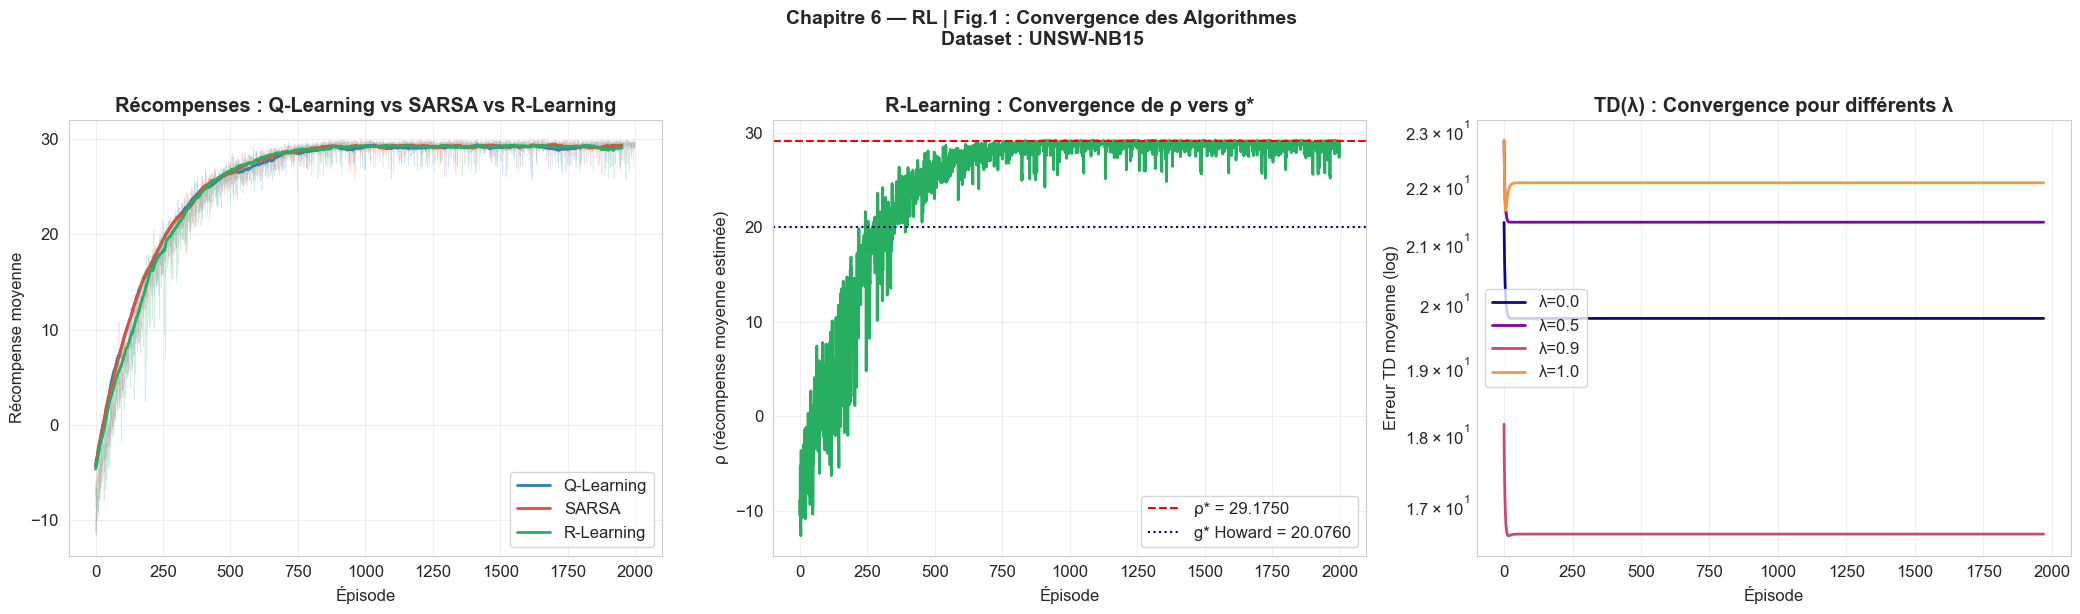

✅ Figure 1 sauvegardée


In [11]:
# ============================================================
# FIGURE 1 : Convergence des récompenses — Q-Learning, SARSA, R-Learning
# ============================================================
def smooth(data, w=50):
    return np.convolve(data, np.ones(w)/w, mode='valid')

fig1, axes = plt.subplots(1, 3, figsize=(21, 6))
fig1.suptitle('Chapitre 6 — RL | Fig.1 : Convergence des Algorithmes\nDataset : UNSW-NB15',
              fontsize=14, fontweight='bold', y=1.02)

# Récompenses Q-Learning vs SARSA
ax = axes[0]
ax.plot(rw_ql,    alpha=0.2, color='#2980b9', lw=0.5)
ax.plot(smooth(rw_ql),    color='#2980b9', lw=2, label='Q-Learning')
ax.plot(rw_sarsa, alpha=0.2, color='#e74c3c', lw=0.5)
ax.plot(smooth(rw_sarsa), color='#e74c3c', lw=2, label='SARSA')
ax.plot(rw_rl,    alpha=0.2, color='#27ae60', lw=0.5)
ax.plot(smooth(rw_rl),    color='#27ae60', lw=2, label='R-Learning')
ax.set_xlabel('Épisode'); ax.set_ylabel('Récompense moyenne')
ax.set_title('Récompenses : Q-Learning vs SARSA vs R-Learning', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

# ρ de R-Learning
ax = axes[1]
ax.plot(rho_hist, color='#27ae60', lw=2)
ax.axhline(y=rho_final, color='red', linestyle='--', label=f'ρ* = {rho_final:.4f}')
ax.axhline(y=g_howard,  color='navy', linestyle=':', label=f'g* Howard = {g_howard:.4f}')
ax.set_xlabel('Épisode'); ax.set_ylabel('ρ (récompense moyenne estimée)')
ax.set_title('R-Learning : Convergence de ρ vers g*', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

# Convergence TD(λ) pour différents λ
ax = axes[2]
cmap = plt.cm.plasma
for i, lam in enumerate(lambdas):
    err = err_tdl[lam]
    ax.semilogy(smooth(err, 30), color=cmap(i/len(lambdas)), lw=2, label=f'λ={lam}')
ax.set_xlabel('Épisode'); ax.set_ylabel('Erreur TD moyenne (log)')
ax.set_title('TD(λ) : Convergence pour différents λ', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('ch6_fig1_convergence.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure 1 sauvegardée')


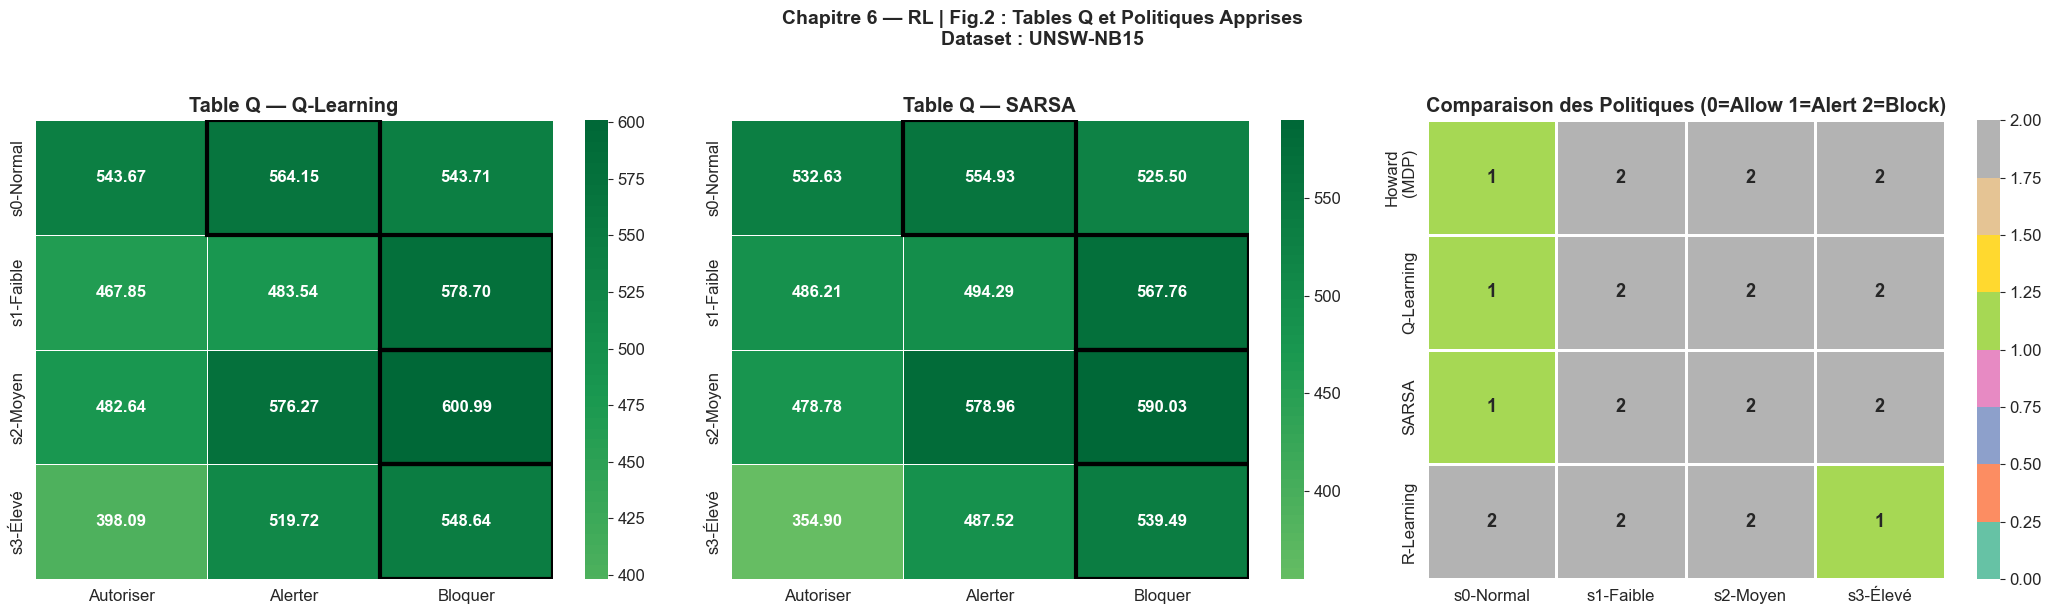

✅ Figure 2 sauvegardée


In [12]:
# ============================================================
# FIGURE 2 : Tables Q, Politiques, Valeurs
# ============================================================
fig2, axes = plt.subplots(1, 3, figsize=(21, 6))
fig2.suptitle('Chapitre 6 — RL | Fig.2 : Tables Q et Politiques Apprises\nDataset : UNSW-NB15',
              fontsize=14, fontweight='bold', y=1.02)

# Heatmap Q — Q-Learning
sns.heatmap(Q_ql, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            xticklabels=[ACTION_NAMES[a] for a in range(N_ACTIONS)],
            yticklabels=[STATE_NAMES[s] for s in range(N_STATES)],
            ax=axes[0], linewidths=0.5, annot_kws={'size':12,'weight':'bold'})
axes[0].set_title('Table Q — Q-Learning', fontweight='bold')
# Marquer politique optimale
for s in range(N_STATES):
    axes[0].add_patch(plt.Rectangle((pi_ql[s], s), 1, 1, fill=False,
                                     edgecolor='black', lw=3))

# Heatmap Q — SARSA
sns.heatmap(Q_sarsa, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            xticklabels=[ACTION_NAMES[a] for a in range(N_ACTIONS)],
            yticklabels=[STATE_NAMES[s] for s in range(N_STATES)],
            ax=axes[1], linewidths=0.5, annot_kws={'size':12,'weight':'bold'})
axes[1].set_title('Table Q — SARSA', fontweight='bold')
for s in range(N_STATES):
    axes[1].add_patch(plt.Rectangle((pi_sarsa[s], s), 1, 1, fill=False,
                                     edgecolor='black', lw=3))

# Comparaison des politiques (toutes)
policy_matrix = np.array([
    pi_howard, pi_ql, pi_sarsa, pi_rl
])
algo_names = ['Howard\n(MDP)', 'Q-Learning', 'SARSA', 'R-Learning']
sns.heatmap(policy_matrix, annot=True, fmt='d', cmap='Set2',
            xticklabels=[STATE_NAMES[s] for s in range(N_STATES)],
            yticklabels=algo_names,
            ax=axes[2], linewidths=1.0,
            annot_kws={'size':13,'weight':'bold'},
            vmin=0, vmax=2)
axes[2].set_title('Comparaison des Politiques (0=Allow 1=Alert 2=Block)',
                   fontweight='bold')

plt.tight_layout()
plt.savefig('ch6_fig2_policies.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure 2 sauvegardée')


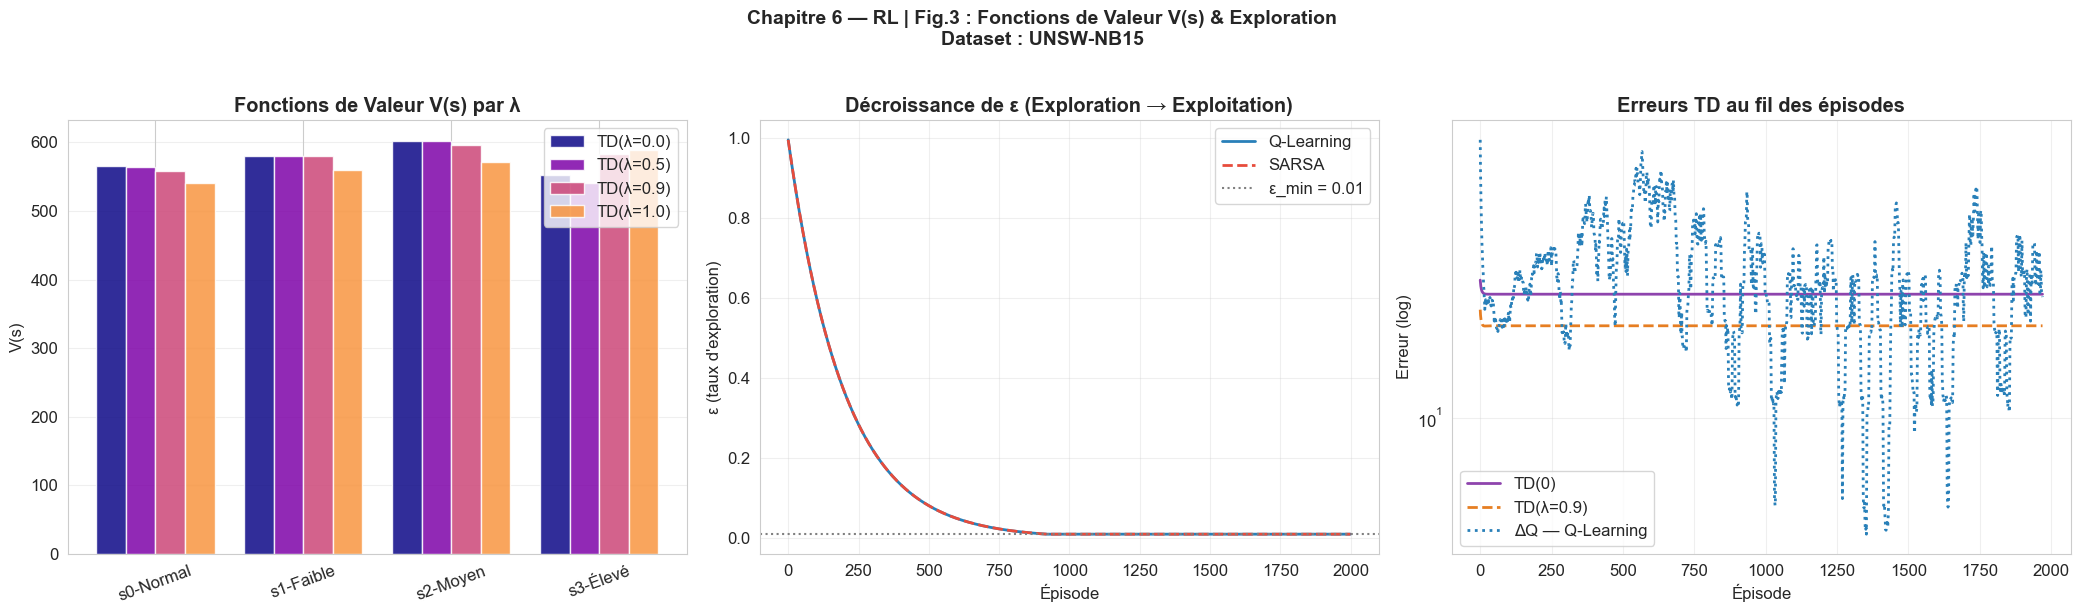

✅ Figure 3 sauvegardée


In [13]:
# ============================================================
# FIGURE 3 : TD(0) vs TD(λ) — Fonctions de Valeur + ε-greedy
# ============================================================
fig3, axes = plt.subplots(1, 3, figsize=(21, 6))
fig3.suptitle('Chapitre 6 — RL | Fig.3 : Fonctions de Valeur V(s) & Exploration\nDataset : UNSW-NB15',
              fontsize=14, fontweight='bold', y=1.02)

# V(s) TD(0) vs TD(λ=0.9)
ax = axes[0]
x  = np.arange(N_STATES)
w  = 0.2
for i, lam in enumerate(lambdas):
    ax.bar(x + i*w, V_tdl_dict[lam], w, label=f'TD(λ={lam})',
           color=plt.cm.plasma(i/len(lambdas)), alpha=0.85)
ax.set_xticks(x + w*1.5)
ax.set_xticklabels([STATE_NAMES[s] for s in range(N_STATES)], rotation=20)
ax.set_ylabel('V(s)')
ax.set_title('Fonctions de Valeur V(s) par λ', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)

# Décroissance ε
ax = axes[1]
ax.plot(eps_ql,    color='#2980b9', lw=2, label='Q-Learning')
ax.plot(eps_sarsa, color='#e74c3c', lw=2, linestyle='--', label='SARSA')
ax.axhline(y=0.01, color='gray', linestyle=':', lw=1.5, label='ε_min = 0.01')
ax.set_xlabel('Épisode'); ax.set_ylabel('ε (taux d\'exploration)')
ax.set_title('Décroissance de ε (Exploration → Exploitation)', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

# Erreur TD au fil des épisodes
ax = axes[2]
ax.semilogy(smooth(td_err_hist, 30), color='#8e44ad', lw=2, label='TD(0)')
ax.semilogy(smooth(err_tdl[0.9], 30), color='#e67e22', lw=2, linestyle='--', label='TD(λ=0.9)')
ax.semilogy(smooth(conv_ql, 30),    color='#2980b9', lw=2, linestyle=':', label='ΔQ — Q-Learning')
ax.set_xlabel('Épisode'); ax.set_ylabel('Erreur (log)')
ax.set_title('Erreurs TD au fil des épisodes', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('ch6_fig3_values.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure 3 sauvegardée')


In [14]:
# ============================================================
# RÉCAPITULATIF FINAL
# ============================================================
print('\n' + '='*75)
print('  RÉCAPITULATIF — CHAPITRE 6 : Apprentissage par Renforcement')
print('='*75)

rows = [
    ['Q-Learning',  'Off-policy',  'TD-Control',  'Oui (γ)',  f'{np.mean(rw_ql[-200:]):.3f}'],
    ['SARSA',       'On-policy',   'TD-Control',  'Oui (γ)',  f'{np.mean(rw_sarsa[-200:]):.3f}'],
    ['TD(0)',       'Prédiction',  'Évaluation π','Oui (γ)',  f'{np.mean(td_err_hist[-200:]):.4f} (err)'],
    ['TD(λ=0.9)',   'Prédiction',  'Élig. Traces','Oui (γ)',  f'{np.mean(err_tdl[0.9][-200:]):.4f} (err)'],
    ['R-Learning',  'Off-policy',  'Avg Reward',  'Non (ρ)',  f'ρ*={rho_final:.3f}'],
    ['Howard(MDP)', 'Analytique',  'PolicyIter',  'Non (g)',  f'g*={g_howard:.3f}'],
]

print(f"  {'Algorithme':15s} {'Type':15s} {'Catégorie':15s} {'Actualisation':15s} {'Perf. finale':15s}")
print(f"  {'-'*76}")
for r in rows:
    print(f"  {r[0]:15s} {r[1]:15s} {r[2]:15s} {r[3]:15s} {r[4]:15s}")

print('\n  Politiques optimales trouvées :')
print(f"  {'État':20s}  {'Howard':12s}  {'Q-Learn':12s}  {'SARSA':12s}  {'R-Learn':12s}")
print(f"  {'-'*72}")
for s in range(N_STATES):
    print(f"  {STATE_NAMES[s]:20s}  {ACTION_NAMES[pi_howard[s]]:12s}  {ACTION_NAMES[pi_ql[s]]:12s}  {ACTION_NAMES[pi_sarsa[s]]:12s}  {ACTION_NAMES[pi_rl[s]]:12s}")

print('\n✅ Chapitre 6 complet — Q-Learning · SARSA · TD(0) · TD(λ) · R-Learning')



  RÉCAPITULATIF — CHAPITRE 6 : Apprentissage par Renforcement
  Algorithme      Type            Catégorie       Actualisation   Perf. finale   
  ----------------------------------------------------------------------------
  Q-Learning      Off-policy      TD-Control      Oui (γ)         29.153         
  SARSA           On-policy       TD-Control      Oui (γ)         29.240         
  TD(0)           Prédiction      Évaluation π    Oui (γ)         19.7674 (err)  
  TD(λ=0.9)       Prédiction      Élig. Traces    Oui (γ)         16.6075 (err)  
  R-Learning      Off-policy      Avg Reward      Non (ρ)         ρ*=29.175      
  Howard(MDP)     Analytique      PolicyIter      Non (g)         g*=20.076      

  Politiques optimales trouvées :
  État                  Howard        Q-Learn       SARSA         R-Learn     
  ------------------------------------------------------------------------
  s0-Normal             Alerter       Alerter       Alerter       Bloquer     
  s1-Faible     